In [ ]:
import os
from kan import *
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
import numpy as np
import torch
import HydroErr as he
from sklearn.linear_model import LinearRegression
from joblib import Parallel, delayed
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [ ]:
base = os.getcwd()  # get current working directory

# Full file path
dir_in = os.path.join(base, "V5.xlsx")

In [3]:
def to_numpy_1d(array_like):
    if isinstance(array_like, torch.Tensor):
        array_like = array_like.detach().cpu().numpy()
    return np.ravel(array_like)

In [ ]:
def model_performance(sim_train, obs_train, sim_test, obs_test, additional_metrics=None):
    sim_train = to_numpy_1d(sim_train)
    obs_train = to_numpy_1d(obs_train)
    sim_test = to_numpy_1d(sim_test)
    obs_test = to_numpy_1d(obs_test)

    metrics = {
        'R^2': he.r_squared,
        'RMSE': he.rmse,
        'KGE': he.kge_2012,
        'NSE': he.nse
    }

    if additional_metrics:
        metrics.update(additional_metrics)

    def evaluate_metrics(sim, obs):
        return {name: func(sim, obs) for name, func in metrics.items()}

    # ----- Linear regression m,q -----
    try:
        lr_train = LinearRegression().fit(obs_train.reshape(-1,1), sim_train)
        m_train = lr_train.coef_[0]
        q_train = lr_train.intercept_
    except:
        m_train, q_train = np.nan, np.nan

    try:
        lr_test = LinearRegression().fit(obs_test.reshape(-1,1), sim_test)
        m_test = lr_test.coef_[0]
        q_test = lr_test.intercept_
    except:
        m_test, q_test = np.nan, np.nan

    train_results = evaluate_metrics(sim_train, obs_train)
    test_results = evaluate_metrics(sim_test, obs_test)

    print(f"\n=== Model performance on training data ===")
    for name, value in train_results.items():
        print(f"{name} (train): {value:.4f}")
    print(f"m (train): {m_train:.4f}")
    print(f"q (train): {q_train:.4f}")

    print(f"\n=== Model performance on test data ===")
    for name, value in test_results.items():
        print(f"{name} (test): {value:.4f}")
    print(f"m (test): {m_test:.4f}")
    print(f"q (test): {q_test:.4f}")


In [ ]:
def average_r2(df_all, opt, lamb, lamb_coef, grid, seed, lib,
               x_labels, y_label='ZTP(km)', n_splits=10,
               random_state=0, verbose=0, return_folds=True,
               oversample_quantile=0.96, oversample_factor=10):

    X_all = df_all[x_labels].copy()
    y_all = df_all[y_label].values.reshape(-1, 1).copy()

    X, X_test_global, y, y_test_global = train_test_split(
        X_all, y_all, test_size=0.2, random_state=random_state
    )

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    list_r2_test = []
    fold_results = []

    for fold, (train_index, test_index) in enumerate(kf.split(X)):

        print(f'\nFold {fold + 1}')

        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # OVERSAMPLING
        threshold = np.quantile(y_train, oversample_quantile)

        high_idx = np.where(y_train.flatten() >= threshold)[0]

        if len(high_idx) > 0:

            X_high = X_train.iloc[high_idx]
            y_high = y_train[high_idx]

            X_high_rep = pd.concat([X_high] * oversample_factor, ignore_index=True)
            y_high_rep = np.vstack([y_high] * oversample_factor)

            X_train = pd.concat([X_train, X_high_rep], ignore_index=True)
            y_train = np.vstack([y_train, y_high_rep])

        X_train_t = torch.from_numpy(X_train.values).float()
        X_test_t = torch.from_numpy(X_test.values).float()
        y_train_t = torch.from_numpy(y_train).float()
        y_test_t = torch.from_numpy(y_test).float()

        dataset = {
            'train_input': X_train_t,
            'test_input': X_test_t,
            'train_label': y_train_t,
            'test_label': y_test_t
        }

        model = KAN(width=[X_train_t.shape[1], 1, 1], grid=grid, k=3, seed=seed, auto_save=False)

        model(dataset['train_input'])
        model.fit(dataset, opt=opt, steps=20, lamb=lamb, lamb_coef=lamb_coef)

        for _ in range(2):
            model.fit(dataset, opt=opt, steps=50, lamb=lamb, lamb_coef=lamb_coef)

        try:
            model.auto_symbolic(lib=lib, weight_simple=0.8)
            model.fit(dataset, opt=opt, steps=20, lamb=lamb, lamb_coef=lamb_coef)
        except:
            pass

        y_train_pred = model(X_train_t)
        y_test_pred = model(X_test_t)

        r2_train = he.r_squared(y_train_pred.detach().numpy()[:, 0], y_train.flatten())
        r2_test = he.r_squared(y_test_pred.detach().numpy()[:, 0], y_test.flatten())

        list_r2_test.append(r2_test)

        eqn = model.symbolic_formula()[0][0]

        if verbose > 0:

            print(f"... KAN eqn: {eqn}")
            print(f"... R^2 train: {r2_train:.4f}")
            print(f"... R^2 test: {r2_test:.4f}")

            y_pred_global = model(torch.from_numpy(X_test_global.values).float())

            model_performance(
                sim_train=model(torch.from_numpy(X.values).float()),
                obs_train=y.flatten(),
                sim_test=y_pred_global,
                obs_test=y_test_global.flatten()
            )

        fold_results.append({
            'fold': fold + 1,
            'X_train': X_train.values,
            'y_train_obs': y_train.copy(),
            'y_train_pred': y_train_pred.detach().numpy(),
            'X_test': X_test.values,
            'y_test_obs': y_test.copy(),
            'y_test_pred': y_test_pred.detach().numpy(),
            'model': model,
            'eqn': eqn
        })

    avg_r2 = np.nanmean(list_r2_test)

    if return_folds:
        return avg_r2, fold_results
    else:
        return avg_r2

In [ ]:
# Load the dataset
df_all = pd.read_excel(dir_in)

In [ ]:
# Parameters
opt = "LBFGS"
lamb = 1e-3 
lamb_coef = 0.0
lib = ['x', 'x^2', 'x^3', 'x^4', 'x^5', 'sin', 'cos', 'exp', 'gaussian', 'tanh']

In [ ]:
# specify the input columns
x_labels = ['CO2', 'N2' , 'O2', 'CH4', 'H2', 'Ar', 'p0', 'T0', 'u0', 'D', 'sp', 'Tamb', 'h']

In [ ]:
seed_range = range(0, 2)
grid_range = range(2, 4)

param_list = list(itertools.product(seed_range, grid_range))

def run_single(seed, grid):

    avg_r2, _ = average_r2(df_all, opt, lamb, lamb_coef, grid, seed, lib, x_labels=x_labels, y_label='ZTP(me-5)', n_splits=10, random_state=5)

    return (seed, grid, avg_r2)

results = Parallel(n_jobs=-1, backend="loky")(delayed(run_single)(seed, grid) for seed, grid in param_list)

best_seed, best_grid, best_r2 = max(results, key=lambda x: x[2])

print(f"Best parameters found:\nSeed: {best_seed}\nGrid: {best_grid}\nBest average R²: {best_r2}")

Best parameters found:
Seed: 0
Grid: 2
Best average R²: 0.8579639164201263


In [ ]:
best_avg, fold_results = average_r2(df_all, opt, lamb, lamb_coef, best_grid, best_seed, lib, x_labels=x_labels, y_label='ZTP(me-5)', n_splits=10, random_state=5, verbose=2)


Fold 1


| train_loss: 3.58e-01 | test_loss: 5.33e-01 | reg: 2.24e+01 | : 100%|█| 20/20 [00:04<00:00,  4.24it
| train_loss: 3.09e-01 | test_loss: 5.79e-01 | reg: 2.18e+01 | : 100%|█| 50/50 [00:10<00:00,  4.66it
| train_loss: 3.97e-01 | test_loss: 7.71e-01 | reg: 2.33e+01 | : 100%|█| 50/50 [00:10<00:00,  4.63it


fixing (0,0,0) with x^2, r2=0.982528567314148, c=2
fixing (0,1,0) with sin, r2=0.9950183033943176, c=2
fixing (0,2,0) with x^5, r2=0.9998946189880371, c=3
fixing (0,3,0) with x, r2=0.7396469712257385, c=1
fixing (0,4,0) with x, r2=0.9684383273124695, c=1
fixing (0,5,0) with x, r2=0.6140460968017578, c=1
fixing (0,6,0) with x^2, r2=0.9997554421424866, c=2
fixing (0,7,0) with x, r2=0.9514146447181702, c=1
fixing (0,8,0) with x^2, r2=1.0000007152557373, c=2
fixing (0,9,0) with x^2, r2=0.9999576807022095, c=2
fixing (0,10,0) with x, r2=0.8909743428230286, c=1
fixing (0,11,0) with exp, r2=1.0000003576278687, c=2
fixing (0,12,0) with x^2, r2=1.0000004768371582, c=2
fixing (1,0,0) with exp, r2=0.9897664189338684, c=2


| train_loss: 4.06e-01 | test_loss: 6.48e-01 | reg: 0.00e+00 | : 100%|█| 20/20 [00:06<00:00,  3.06it


... KAN eqn: 1.17625213370413*exp(17.8336855201117*x_11 + 2.11765128836061*x_4 - 12.3034689428872*x_5 - 3.96405695447929*x_6 + 0.0145847262516551*x_8 + 1.91846828660894*(0.00967305174487633 - x_10)**2 + 16.3836579045068*(0.819942603126164 - x_1)**2 + 0.0465492375570375*(1 - 0.373885283546618*x_13)**2 - 5.88095410474791*(1 - 0.0489611566770767*x_7)**2 - 0.552975502476024*(1 - 0.709856446132422*x_9)**2 - 255.605421699407*(-x_3 - 0.109211221095081)**5 + 0.200294217005217*sin(9.99537658691406*x_2 - 5.51631450653076) + 0.314895401821499*exp(-0.0630287975072861*x_12)) + 0.239283189177513
... R^2 train: 0.9804
... R^2 test: 0.7886

=== Model performance on training data ===
R^2 (train): 0.9153
RMSE (train): 0.4748
KGE (train): 0.9541
NSE (train): 0.9123
m (train): 0.9653
q (train): 0.0925

=== Model performance on test data ===
R^2 (test): 0.9199
RMSE (test): 0.5773
KGE (test): 0.9272
NSE (test): 0.9018
m (test): 1.0295
q (test): 0.0646

Fold 2


...

... KAN eqn: 0.0764855217331275*exp(13.0300448238566*x_11 - 1.65597999124944*x_3 - 1.16766734769543*x_4 - 7.51608071245926*x_5 + 0.121011950561942*x_7 + 0.0176812057804781*x_8 + 8.77632223316351*(0.800707679766792 - x_1)**2 - 0.0163694291221585*(1 - 0.128576136867362*x_12)**2 + 3.90023500094941*(1 - 0.200757364038528*x_9)**2 + 0.660152351352593*cos(4.15143823623657*x_10 + 8.21871948242188) + 0.279215540560344*exp(-9.99977970123291*x_6) + 0.106270422719239*exp(-9.57728004455566*x_2) - 0.130154347944365*exp(-1.19343984127045*x_13)) + 0.0445517525076866
... R^2 train: 0.9776
... R^2 test: 0.7357

=== Model performance on training data ===
R^2 (train): 0.9256
RMSE (train): 0.4379
KGE (train): 0.9474
NSE (train): 0.9254
m (train): 0.9343
q (train): 0.1374

=== Model performance on test data ===
R^2 (test): 0.9129
RMSE (test): 0.5970
KGE (test): 0.9142
NSE (test): 0.8950
m (test): 1.0395
q (test): -0.0542

Fold 10


| train_loss: 4.14e-01 | test_loss: 7.16e-01 | reg: 1.54e+01 | : 100%|█| 20/20 [00:05<00:00,  3.93it
| train_loss: 3.74e-01 | test_loss: 7.09e-01 | reg: 1.50e+01 | : 100%|█| 50/50 [00:12<00:00,  4.00it
| train_loss: 6.21e-01 | test_loss: 8.80e-01 | reg: 1.49e+01 | : 100%|█| 50/50 [00:08<00:00,  5.94it


fixing (0,0,0) with x^2, r2=0.9991578459739685, c=2
fixing (0,1,0) with x^2, r2=0.9985604286193848, c=2
fixing (0,2,0) with x, r2=0.875324010848999, c=1
fixing (0,3,0) with x, r2=0.051831528544425964, c=1
fixing (0,4,0) with x, r2=0.6968141198158264, c=1
fixing (0,5,0) with x, r2=0.32267358899116516, c=1
fixing (0,6,0) with x, r2=0.9956017136573792, c=1
fixing (0,7,0) with x^2, r2=0.998643696308136, c=2
fixing (0,8,0) with x^2, r2=1.0000004768371582, c=2
fixing (0,9,0) with cos, r2=0.9999801516532898, c=2
fixing (0,10,0) with x, r2=0.9791171550750732, c=1
fixing (0,11,0) with x^2, r2=1.0000003576278687, c=2
fixing (0,12,0) with x^2, r2=1.0000004768371582, c=2
fixing (1,0,0) with exp, r2=0.9963913559913635, c=2


| train_loss: 4.31e-01 | test_loss: 6.74e-01 | reg: 0.00e+00 | : 100%|█| 20/20 [00:04<00:00,  4.27it


... KAN eqn: 0.0975836956976194*exp(11.8155736921853*x_11 - 0.891514786974045*x_3 + 0.259463738735301*x_4 - 5.93546564596473*x_5 + 1.46903023542274*x_6 + 0.126539885158571*x_7 - 2.38192023780302*(0.204055461633411 - x_2)**2 + 19.7953849146634*(0.804520181395614 - x_1)**2 - 0.0703294218390821*(1 - 0.0797414691654464*x_12)**2 - 0.0426730061173946*(1 - 0.256345348070267*x_13)**2 + 5.31077254243153*(1 - 0.258310818009749*x_9)**2 + 0.0506728322041805*(-0.0710059854089953*x_8 - 1)**2 - 0.613354678335611*cos(4.64080619812012*x_10 + 4.82959747314453)) + 0.243238970637321
... R^2 train: 0.9783
... R^2 test: 0.8018

=== Model performance on training data ===
R^2 (train): 0.9097
RMSE (train): 0.4863
KGE (train): 0.8957
NSE (train): 0.9080
m (train): 0.9010
q (train): 0.2519

=== Model performance on test data ===
R^2 (test): 0.8801
RMSE (test): 0.7201
KGE (test): 0.8895
NSE (test): 0.8473
m (test): 1.0475
q (test): -0.0466


In [ ]:
def plot_predictions_single_output(df_all, fold_results, x_labels, y_label='ZTP(me-5)', random_state=5):

    X_all = df_all[x_labels].copy()
    y_all = df_all[y_label].values.reshape(-1, 1).copy()

    X_train_gl, X_test_gl, y_train_gl, y_test_gl = train_test_split(
        X_all, y_all, test_size=0.2, random_state=random_state
    )

    X_train_t = torch.from_numpy(X_train_gl.values).float()
    X_test_t = torch.from_numpy(X_test_gl.values).float()

    for i, fold in enumerate(fold_results):

        # Check if the model exist
        if 'model' not in fold or fold['model'] is None:
            print(f"Fold {fold.get('fold', i+1)} saltato: modello non disponibile.")
            continue


        model = fold['model']

        # Prediction on global train and test
        try:
            y_train_pred = model(X_train_t).detach().numpy()
            y_test_pred = model(X_test_t).detach().numpy()
        except Exception as e:
            print(f"Fold {fold.get('fold', i+1)} saltato: errore durante predizione ({e})")
            continue

        # Check NaN
        if np.isnan(y_train_pred).any() or np.isnan(y_test_pred).any():
            print(f"Fold {fold.get('fold', i+1)} saltato: predizioni contengono NaN")
            continue

        y_obs_all = np.concatenate([y_train_gl.flatten(), y_test_gl.flatten()])
        y_pred_all = np.concatenate([y_train_pred, y_test_pred])

        plt.figure(figsize=(6,5))

        plt.scatter(y_train_gl, y_train_pred, alpha=0.6, label='Train (80%)')
        plt.scatter(y_test_gl, y_test_pred, alpha=0.6, label='Test (20%)')

        min_val = min(y_obs_all.min(), y_pred_all.min())
        max_val = max(y_obs_all.max(), y_pred_all.max())
        plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Bisettrice')

       

        lr = LinearRegression().fit(y_obs_all.reshape(-1,1), y_pred_all)
        r2 = lr.score(y_obs_all.reshape(-1,1), y_pred_all)
        m = float(lr.coef_.ravel()[0])
        q = float(np.array(lr.intercept_).ravel()[0])


        txt = f"R²: {r2:.3f}\nm: {m:.3f}\nq: {q:.3f}"
        plt.text(0.05, 0.95, txt, transform=plt.gca().transAxes,
                 va='top', bbox=dict(facecolor='white', alpha=0.8))

        plt.xlabel("Osservato")
        plt.ylabel("Predetto")
        plt.title(f"Fold {fold['fold']} – {y_label}")
        plt.legend(loc='lower right', fontsize=14)
        plt.grid(True)

        plt.show()

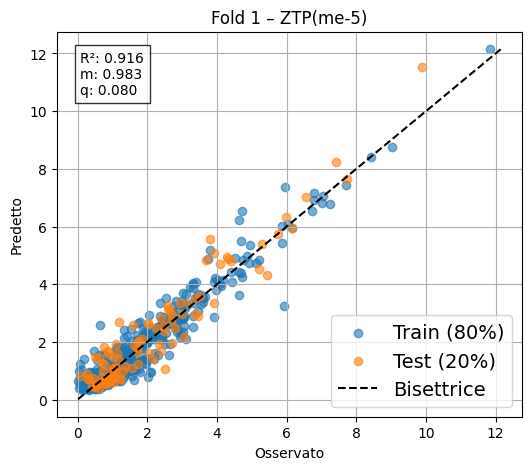

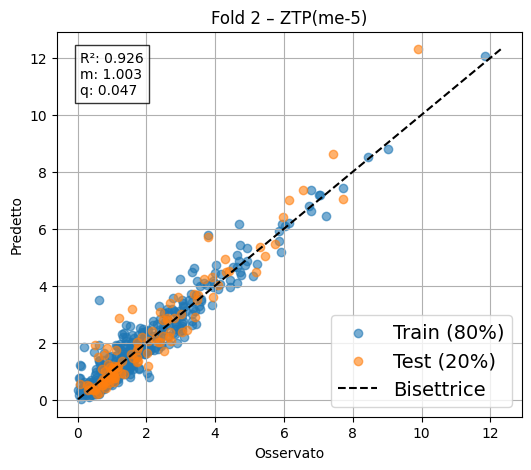

Fold 3 saltato: predizioni contengono NaN
Fold 4 saltato: predizioni contengono NaN


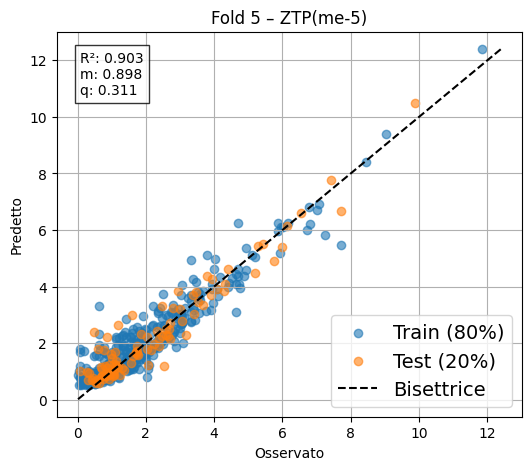

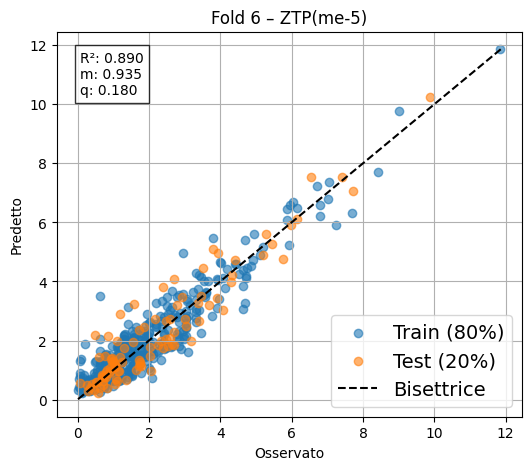

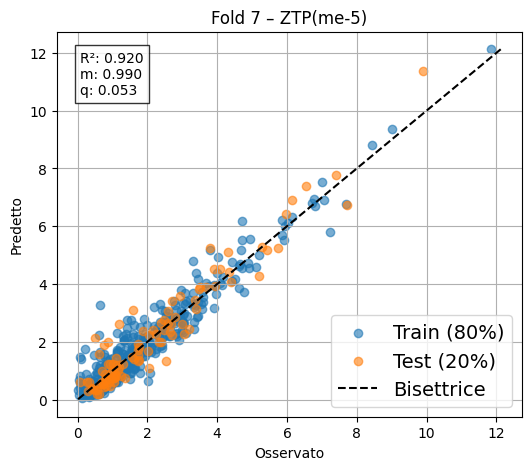

Fold 8 saltato: predizioni contengono NaN


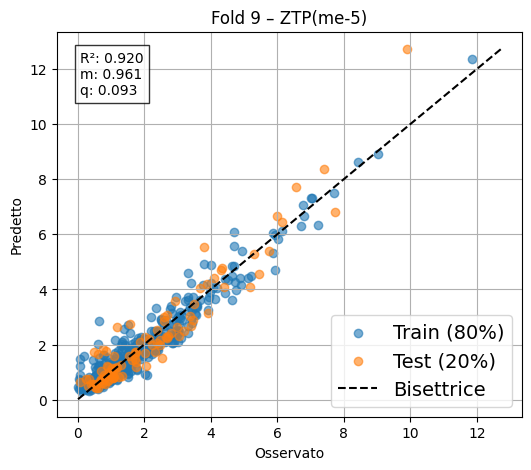

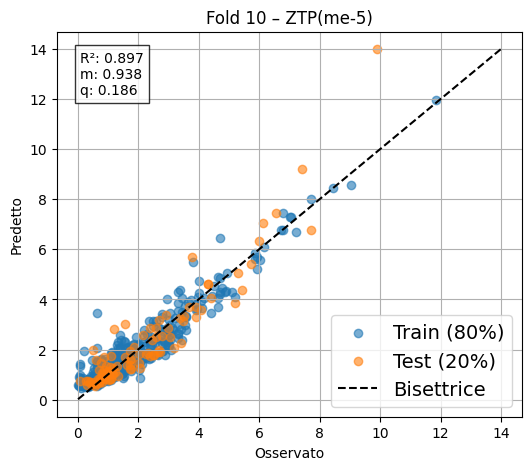

In [11]:
plot_predictions_single_output(df_all, fold_results, x_labels=x_labels, y_label='ZTP(me-5)', random_state=5)

In [ ]:
def plot_train_test_for_single_fold(df_all, fold_results, fold_number,
                                    x_labels, y_label, random_state=5):
    
    # Check if the fold exist
    selected = None
    for fr in fold_results:
        if fr.get("fold", None) == fold_number:
            selected = fr
            break

    if selected is None or selected.get("model", None) is None:
        print(f"Fold {fold_number} non trovato o modello non disponibile.")
        return

    model = selected["model"]

    X_all = df_all[x_labels].copy()
    y_all = df_all[y_label].values.reshape(-1, 1)

    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, test_size=0.2, random_state=random_state
    )

    X_train_t = torch.from_numpy(X_train.values).float()
    X_test_t = torch.from_numpy(X_test.values).float()

    # Predictions
    y_pred_train = model(X_train_t).detach().numpy().flatten()
    y_pred_test  = model(X_test_t).detach().numpy().flatten()

    y_train_flat = y_train.flatten()
    y_test_flat  = y_test.flatten()

    # Train metrics
    r2_train = r2_score(y_train_flat, y_pred_train)
    lr_train = LinearRegression().fit(y_train_flat.reshape(-1,1), y_pred_train)
    m_train = lr_train.coef_[0]
    q_train = lr_train.intercept_
    r2_lr_train = lr_train.score(y_train_flat.reshape(-1,1), y_pred_train)

    # Test metrics
    r2_test = r2_score(y_test_flat, y_pred_test)
    lr_test = LinearRegression().fit(y_test_flat.reshape(-1,1), y_pred_test)
    m_test = lr_test.coef_[0]
    q_test = lr_test.intercept_
    r2_lr_test = lr_test.score(y_test_flat.reshape(-1,1), y_pred_test)

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # ---------------- TRAIN ----------------
    ax[0].scatter(y_train_flat, y_pred_train, alpha=0.7, color='blue')

    min_val = min(y_train_flat.min(), y_pred_train.min())
    max_val = max(y_train_flat.max(), y_pred_train.max())

    # bisector line
    ax[0].plot([min_val, max_val], [min_val, max_val], 'k--')

    # regression line
    x_line = np.linspace(min_val, max_val, 100)
    y_line = m_train * x_line + q_train
    ax[0].plot(x_line, y_line, color='red', linewidth=2)

    ax[0].set_title(f"Fold {fold_number} – TRAIN")
    ax[0].set_xlabel("Osservato")
    ax[0].set_ylabel("Predetto")
    ax[0].grid(True)

    txt_train = f"R²: {r2_lr_train:.3f}\nm: {m_train:.3f}\nq: {q_train:.3f}"
    ax[0].text(0.05, 0.95, txt_train,
               transform=ax[0].transAxes,
               va='top',
               bbox=dict(facecolor='white', alpha=0.8))

    # ---------------- TEST ----------------
    ax[1].scatter(y_test_flat, y_pred_test, alpha=0.7, color='orange')

    min_val = min(y_test_flat.min(), y_pred_test.min())
    max_val = max(y_test_flat.max(), y_pred_test.max())

    # bisector line
    ax[1].plot([min_val, max_val], [min_val, max_val], 'k--')

    # regression line
    x_line = np.linspace(min_val, max_val, 100)
    y_line = m_test * x_line + q_test
    ax[1].plot(x_line, y_line, color='red', linewidth=2)

    ax[1].set_title(f"Fold {fold_number} – TEST")
    ax[1].set_xlabel("Osservato")
    ax[1].set_ylabel("Predetto")
    ax[1].grid(True)

    txt_test = f"R²: {r2_lr_test:.3f}\nm: {m_test:.3f}\nq: {q_test:.3f}"
    ax[1].text(0.05, 0.95, txt_test,
               transform=ax[1].transAxes,
               va='top',
               bbox=dict(facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

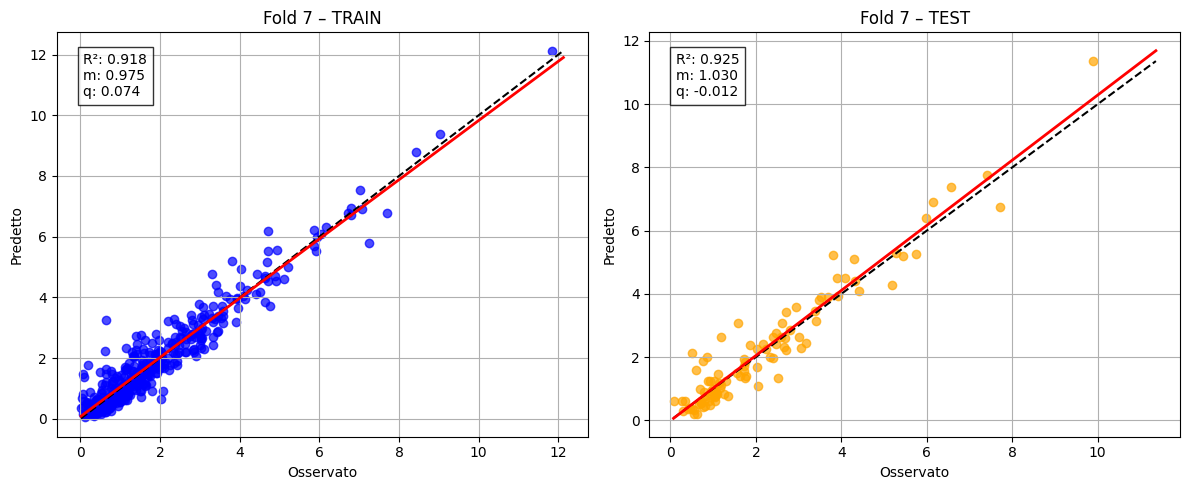

In [16]:
plot_train_test_for_single_fold(df_all, fold_results, fold_number=7, x_labels=x_labels, y_label='ZTP(me-5)')